# Financial Sentiment Analysis with RoBERTa

This notebook shows the steps taken to further training a RoBERTa model for financial sentiment classification. We combine multiple financial datasets to create a model that can classify text as negative, neutral, or positive. The best model has been uploaded to hugging face : alasteirho/FIN-RoBERTa-Custom

## Setup and Imports
Import the necessary libraries for data processing, model training, and evaluation.

In [88]:
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5080


## Load Financial Datasets

We use five different financial sentiment datasets:
1. **Financial PhraseBank** - Sentences with sentiment labels from financial news
2. **Twitter Financial News** - Sentiment from financial tweets
3. **FiQA** - Financial question-answer sentiment data
4. **SemEval 2017 Subtask 2** - Financial news headlines with sentiment scores
5. **SemEval 2017 Subtask 1** - Financial microblogs (tweets/StockTwits) with sentiment scores

In [89]:

fpb_50agree  = load_dataset("takala/financial_phrasebank", "sentences_50agree",  revision="refs/pr/10")["train"]
fpb_allagree = load_dataset("takala/financial_phrasebank", "sentences_allagree", revision="refs/pr/10")["train"]

print(f"FPB 50% Agree samples: {len(fpb_50agree)} (for training)")
print(f"FPB All Agree samples: {len(fpb_allagree)} (will be used for secondary evaluation)")
print(f"\nColumns: {fpb_50agree.column_names}")
print(f"Label distribution (50% agree): {pd.Series(fpb_50agree['label']).value_counts().to_dict()}")
print(f"Label distribution (all agree): {pd.Series(fpb_allagree['label']).value_counts().to_dict()}")
print(f"\nExample: {fpb_50agree[0]}")

FPB 50% Agree samples: 4846 (for training)
FPB All Agree samples: 2264 (will be used for secondary evaluation)

Columns: ['sentence', 'label']
Label distribution (50% agree): {1: 2879, 2: 1363, 0: 604}
Label distribution (all agree): {1: 1391, 2: 570, 0: 303}

Example: {'sentence': 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .', 'label': 1}


In [90]:
twitter_fin = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train")

print(f"Twitter samples: {len(twitter_fin)}")
print(f"Columns: {twitter_fin.column_names}")
print(f"Label distribution: {pd.Series(twitter_fin['label']).value_counts().to_dict()}")
print(f"\nExample: {twitter_fin[0]}")

Twitter samples: 9543
Columns: ['text', 'label']
Label distribution: {2: 6178, 1: 1923, 0: 1442}

Example: {'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}


In [91]:
fiqa = load_dataset("pauri32/fiqa-2018")

print(f"FiQA splits: {fiqa}")
print(f"Columns: {fiqa['train'].column_names}")
print(f"\nExample: {fiqa['train'][0]}")

FiQA splits: DatasetDict({
    train: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 961
    })
    validation: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 102
    })
    test: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 150
    })
})
Columns: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label']

Example: {'sentence': 'Still short $LNG from $11.70 area...next stop could be down through $9.00. Someone slammed it hard with 230,000 shs this am! More to follow', 'snippets': "['Still short $LNG from $11.70 area...next stop could be down through $9.00.']", 'target': 'LNG', 'sentiment_score': -0.543, 'aspects': "['Stock/Price Action/Volatility/Short Selling']", 'format': 'post', 'label': 2}


### Load SemEval 2017

**Subtask 2** contains financial news headlines with continuous sentiment scores.

**Subtask 1** contains financial microblogs (tweets and StockTwits posts) with continuous sentiment scores.

In [92]:
import json
from pathlib import Path

# --- Subtask 2: News Headlines ---
semeval2_path = Path("semeval-2017-task-5-subtask-2") / "Headline_Trainingdata.json"

with open(semeval2_path, "r", encoding="utf-8") as f:
    semeval2_data = json.load(f)

semeval2_df = pd.DataFrame(semeval2_data)
semeval2_df = semeval2_df.rename(columns={"title": "text", "sentiment": "sentiment_score"})

print(f"SemEval 2017 Subtask 2 (headlines): {len(semeval2_df)}")
print(f"  Score range: [{semeval2_df["sentiment_score"].min():.3f}, {semeval2_df["sentiment_score"].max():.3f}]")

# --- Subtask 1: Microblogs ---
semeval1_path = Path("semeval-2017-task-5-subtask-1") / "Microblog_Trainingdata.json"

with open(semeval1_path, "r", encoding="utf-8") as f:
    semeval1_data = json.load(f)

semeval1_df = pd.DataFrame(semeval1_data)
semeval1_df["text"] = semeval1_df["spans"].apply(lambda s: " ".join(s) if isinstance(s, list) else str(s))
semeval1_df["sentiment_score"] = semeval1_df["sentiment score"].astype(float)
semeval1_df = semeval1_df.drop(columns=["spans", "sentiment score"])

print(f"SemEval 2017 Subtask 1 (microblogs): {len(semeval1_df)}")
print(f"  Score range: [{semeval1_df["sentiment_score"].min():.3f}, {semeval1_df["sentiment_score"].max():.3f}]")

# Combine both subtasks
semeval_df = pd.concat([semeval2_df[["text", "sentiment_score"]], semeval1_df[["text", "sentiment_score"]]], ignore_index=True)
print(f"SemEval 2017 combined: {len(semeval_df)}")
print(f"Score range: [{semeval_df["sentiment_score"].min():.3f}, {semeval_df["sentiment_score"].max():.3f}]")
semeval_df.head()

SemEval 2017 Subtask 2 (headlines): 1142
  Score range: [-0.989, 0.989]
SemEval 2017 Subtask 1 (microblogs): 1700
  Score range: [-0.866, 1.000]
SemEval 2017 combined: 2842
Score range: [-0.989, 1.000]


,text,sentiment_score
0,Morrisons book second consecutive quarter of s...,0.430
1,IMI posts drop in first-quarter organic revenu...,-0.344
2,Glencore to refinance its short-term debt earl...,0.340
3,EasyJet attracts more passengers in June but s...,0.259
4,Barclays 'bad bank' chief to step down,-0.231


## Standardize Labels

All datasets need to use the same label format:
- **0** = Negative
- **1** = Neutral  
- **2** = Positive

For datasets with continuous sentiment scores, we convert them to discrete labels using thresholds.

In [93]:
def standardise_fpb(dataset):
    df = pd.DataFrame(dataset)
    df = df.rename(columns={'sentence': 'text', 'label': 'sentiment'})
    return df[['text', 'sentiment']]

def standardise_twitter(dataset):
    df = pd.DataFrame(dataset)
    df = df.rename(columns={'label': 'sentiment'})
    return df[['text', 'sentiment']]

def standardise_fiqa(dataset):
    df = pd.DataFrame(dataset)
    
    def score_to_label(score):
        if score < -0.2:
            return 0
        elif score > 0.2:
            return 2
        else:
            return 1
    
    df['sentiment'] = df['sentiment_score'].apply(score_to_label)
    df = df.rename(columns={'sentence': 'text'})
    return df[['text', 'sentiment']]

def standardise_semeval(df):
    def score_to_label(score):
        if score < -0.2:
            return 0
        elif score > 0.2:
            return 2
        else:
            return 1
    
    df = df.copy()
    df['sentiment'] = df['sentiment_score'].apply(score_to_label)
    return df[['text', 'sentiment']]

fpb_50_df = standardise_fpb(fpb_50agree)
fpb_allagree_df = standardise_fpb(fpb_allagree)
twitter_df = standardise_twitter(twitter_fin)
fiqa_df = standardise_fiqa(fiqa['train'])
semeval_df_clean = standardise_semeval(semeval_df)

print("Dataset sizes:")
print(f"  FPB 50% Agree (train): {len(fpb_50_df)}")
print(f"  FPB All Agree (eval):  {len(fpb_allagree_df)}")
print(f"  Twitter: {len(twitter_df)}")
print(f"  FiQA: {len(fiqa_df)}")
print(f"  SemEval 2017: {len(semeval_df_clean)}")

print("\nLabel distributions:")
for name, df in [('FPB 50%', fpb_50_df), ('Twitter', twitter_df), ('FiQA', fiqa_df), ('SemEval', semeval_df_clean)]:
    dist = df['sentiment'].value_counts().sort_index().to_dict()
    print(f"  {name}: {dist}")

Dataset sizes:
  FPB 50% Agree (train): 4846
  FPB All Agree (eval):  2264
  Twitter: 9543
  FiQA: 961
  SemEval 2017: 2842

Label distributions:
  FPB 50%: {0: 604, 1: 2879, 2: 1363}
  Twitter: {0: 1442, 1: 1923, 2: 6178}
  FiQA: {0: 269, 1: 128, 2: 564}
  SemEval: {0: 831, 1: 584, 2: 1427}


## Create Train/Validation Splits

We split the data as follows:
- FPB 50% Agree: 80% train, 20% validation
- Twitter: Uses native train/validation splits (Defined on hugging face)
- FiQA: Train split for training, test split for validation 
- SemEval: 90% train, 10% validation

The FPB All Agree subset is reserved for final evaluation.

In [94]:
fpb_train, fpb_val = train_test_split(
    fpb_50_df, test_size=0.20, stratify=fpb_50_df['sentiment'], random_state=42
)

print(f"FPB 50% Agree splits:")
print(f"  Train: {len(fpb_train)} ({len(fpb_train)/len(fpb_50_df)*100:.1f}%)")
print(f"  Val:   {len(fpb_val)} ({len(fpb_val)/len(fpb_50_df)*100:.1f}%)")

twitter_train = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train")
twitter_val = load_dataset("zeroshot/twitter-financial-news-sentiment", split="validation")
twitter_train_df = standardise_twitter(twitter_train)
twitter_val_df = standardise_twitter(twitter_val)

fiqa_train_df = standardise_fiqa(fiqa['train'])
fiqa_val_df = standardise_fiqa(fiqa['test'])

semeval_train_df, semeval_val_df = train_test_split(
    semeval_df_clean, test_size=0.1, stratify=semeval_df_clean['sentiment'], random_state=42
)

train_df = pd.concat([fpb_train, twitter_train_df, fiqa_train_df, semeval_train_df], ignore_index=True)
train_df = train_df.dropna().drop_duplicates(subset=['text'])
train_df['text'] = train_df['text'].str.replace('A', '', regex=False)

print(f"\nTotal training samples: {len(train_df)}")
print(f"Train label distribution:\n{train_df['sentiment'].value_counts().sort_index()}")

FPB 50% Agree splits:
  Train: 3876 (80.0%)
  Val:   970 (20.0%)

Total training samples: 16127
Train label distribution:
sentiment
0    2752
1    4723
2    8652
Name: count, dtype: int64


In [95]:
val_df = pd.concat([fpb_val, twitter_val_df, fiqa_val_df, semeval_val_df], ignore_index=True)
val_df = val_df.dropna().drop_duplicates(subset=['text'])
val_df['text'] = val_df['text'].str.replace('A', '', regex=False)

print(f"Total validation samples: {len(val_df)}")
print(f"Val label distribution:\n{val_df['sentiment'].value_counts().sort_index()}")

Total validation samples: 3774
Val label distribution:
sentiment
0     588
1    1171
2    2015
Name: count, dtype: int64


## Convert to HuggingFace Dataset

Transform the pandas DataFrames into HuggingFace Dataset objects for compatibility with the Trainer API.

In [96]:
train_dataset = Dataset.from_pandas(train_df[['text', 'sentiment']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'sentiment']].reset_index(drop=True))

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment'],
        num_rows: 16127
    })
    validation: Dataset({
        features: ['text', 'sentiment'],
        num_rows: 3774
    })
})


## Tokenization

We use the RoBERTa tokenizer with a max length of 128 tokens. The tokenizer converts text into numerical input IDs and attention masks.

In [97]:
model_name = "roberta-base"

tokenizer = RobertaTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.rename_column('sentiment', 'labels')
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(tokenized_dataset)

Map:   0%|          | 0/16127 [00:00<?, ? examples/s]

Map:   0%|          | 0/3774 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 16127
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 3774
    })
})


## Load the Model

We use RoBERTa-base with a classification head for 3 labels. The model is moved to GPU if available.

In [98]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="single_label_classification"
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 124,647,939
Trainable parameters: 124,647,939
Device: cuda


## Define Evaluation Metrics

We track accuracy, macro F1, and weighted F1 scores during training.

In [99]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

## Configure Training Arguments

Key hyperparameters:
- **Learning rate**: 2e-5 with linear decay
- **Batch size**: 16 with gradient accumulation (effective batch size = 32)
- **Early stopping**: Patience of 2 epochs based on validation loss
- **Weight decay**: 0.01 for regularization

In [100]:
from transformers import EarlyStoppingCallback
import os

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir="./model-checkpoints",
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available(),
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=8)

print("Training arguments configured")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Scheduler: {training_args.lr_scheduler_type}")
print(f"  Best model metric: {training_args.metric_for_best_model}")
print(f"  Early stopping patience: 8 epochs")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments configured
  Epochs: 30
  Effective batch size: 32
  Scheduler: SchedulerType.COSINE
  Best model metric: eval_f1_macro
  Early stopping patience: 8 epochs


## Train the Model

Initialize the Trainer and start the training loop.

In [101]:
import time

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

# Record VRAM before training
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    vram_before = torch.cuda.memory_allocated() / 1024**3

print("Further training model")
train_start = time.time()
trainer.train()
train_end = time.time()
train_elapsed = train_end - train_start

# Record VRAM after training
if torch.cuda.is_available():
    vram_peak = torch.cuda.max_memory_allocated() / 1024**3
    vram_after = torch.cuda.memory_allocated() / 1024**3

Further training model


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.059246,0.469442,0.813461,0.797306,0.812853
2,0.942601,0.422764,0.837043,0.827581,0.837527
3,0.705193,0.373056,0.847377,0.832709,0.847266
4,0.628552,0.436726,0.847377,0.832618,0.846998
5,0.403032,0.453829,0.862215,0.849579,0.862984
6,0.336500,0.508514,0.866985,0.855638,0.866473
7,0.221414,0.589234,0.856651,0.845578,0.857532
8,0.162206,0.691743,0.868574,0.854092,0.867771
9,0.179582,0.753544,0.855591,0.843808,0.855230
10,0.157270,0.804387,0.869104,0.857116,0.868690


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

## Training Statistics

GPU VRAM usage and execution times for training and evaluation.

In [102]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

print("TRAINING STATISTICS")

# GPU info
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {gpu_name}")
    print(f"GPU Memory: {vram_total:.2f} GB")

# Execution time
train_mins = train_elapsed / 60
print(f"Training time: {train_elapsed:.1f}s ({train_mins:.2f} min)")

# VRAM
if torch.cuda.is_available():
    print(f"VRAM used for training: {vram_peak:.2f} GB")

# Evaluation inference VRAM + time
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

eval_start = time.time()
eval_results = trainer.evaluate()
eval_elapsed = time.time() - eval_start

if torch.cuda.is_available():
    vram_peak_eval = torch.cuda.max_memory_allocated() / 1024**3
    print(f"VRAM used for inference: {vram_peak_eval:.2f} GB")

print(f"Evaluation time: {eval_elapsed:.2f}s")

TRAINING STATISTICS
GPU: NVIDIA GeForce RTX 5080
GPU Memory: 15.92 GB
Training time: 838.1s (13.97 min)
VRAM used for training: 3.35 GB
VRAM used for inference: 2.14 GB
Evaluation time: 1.77s


## Evaluate on Validation Set

In [103]:
results = trainer.evaluate()

print("\nValidation Results:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")


Validation Results:
eval_loss: 1.0106
eval_accuracy: 0.8755
eval_f1_macro: 0.8631
eval_f1_weighted: 0.8746
eval_runtime: 1.7815
eval_samples_per_second: 2118.4710
eval_steps_per_second: 66.2370
epoch: 23.0000


## Training Analysis

Visualize training and validation metrics to check for overfitting or underfitting.

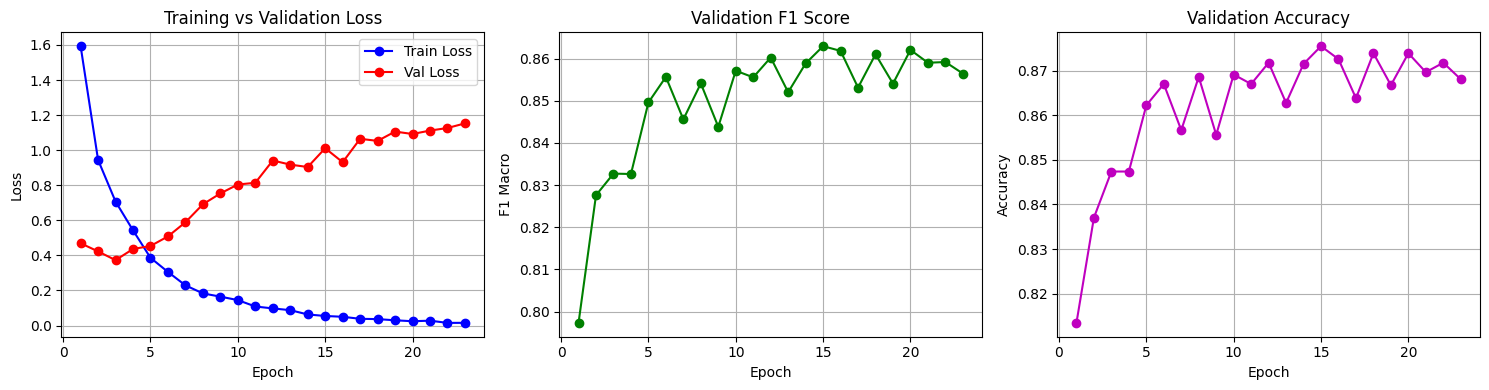


Best validation F1 (macro): 0.8629 at epoch 15.0


In [104]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_loss = [(log['epoch'], log['loss']) for log in history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in history if 'eval_loss' in log]

seen_epochs = set()
unique_eval_logs = []
for log in eval_logs:
    ep = log['epoch']
    if ep not in seen_epochs:
        seen_epochs.add(ep)
        unique_eval_logs.append(log)
eval_logs = unique_eval_logs

epochs = [log['epoch'] for log in eval_logs]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_f1 = [log['eval_f1_macro'] for log in eval_logs]
eval_acc = [log['eval_accuracy'] for log in eval_logs]

train_epochs = sorted(set([int(e) for e, _ in train_loss]))
train_loss_per_epoch = []
for ep in train_epochs:
    losses = [l for e, l in train_loss if int(e) == ep or (ep == 0 and e < 1)]
    if losses:
        train_loss_per_epoch.append(np.mean(losses))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, len(train_loss_per_epoch)+1), train_loss_per_epoch, 'b-o', label='Train Loss')
axes[0].plot(epochs, eval_loss, 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, eval_f1, 'g-o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Macro')
axes[1].set_title('Validation F1 Score')
axes[1].grid(True)

axes[2].plot(epochs, eval_acc, 'm-o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy')
axes[2].grid(True)

plt.tight_layout()
plt.show()
print(f"\nBest validation F1 (macro): {max(eval_f1):.4f} at epoch {epochs[eval_f1.index(max(eval_f1))]}")

## Classification Report

Get detailed per-class metrics on the validation set.

In [105]:
predictions = trainer.predict(tokenized_dataset['validation'])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

label_names = ['negative', 'neutral', 'positive']

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=label_names))


Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.83      0.84       588
     neutral       0.88      0.81      0.84      1171
    positive       0.88      0.93      0.90      2015

    accuracy                           0.88      3774
   macro avg       0.87      0.86      0.86      3774
weighted avg       0.88      0.88      0.87      3774



## Model Summary

Summary of the model configuration and training hyperparameters.

In [106]:
# Model and Hyperparameters Summary for Final Evaluatio
print("MODEL CONFIGURATION & HYPERPARAMETERS")

# Model info
print(f"\n Model:")
print(f"    Base model: {model_name}")
print(f"    Architecture: RoBERTa for Sequence Classification")
print(f"    Number of labels: 3 (negative, neutral, positive)")
print(f"    Total parameters: {total_params:,}")
print(f"    Trainable parameters: {trainable_params:,}")

# Training hyperparameters
print(f"\n Training Hyperparameters:")
print(f"    Max epochs: {training_args.num_train_epochs}")
print(f"    Actual epochs trained: {int(trainer.state.epoch)}")
print(f"    Batch size (train): {training_args.per_device_train_batch_size}")
print(f"    Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"    Gradient accumulation steps: {training_args.gradient_accumulation_steps}")
print(f"    Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"    Learning rate: {training_args.learning_rate}")
print(f"    Weight decay: {training_args.weight_decay}")
print(f"    Warmup ratio: {training_args.warmup_ratio}")
print(f"    LR scheduler: {training_args.lr_scheduler_type}")
print(f"    FP16 training: {training_args.fp16}")

# Early stopping info
print(f"\n Early Stopping:")
print(f"    Patience: {early_stopping.early_stopping_patience}")
print(f"    Metric for best model: {training_args.metric_for_best_model}")
print(f"    Best checkpoint: {trainer.state.best_model_checkpoint}")

# Dataset info
print(f"\n Dataset:")
print(f"    Training samples: {len(train_df):,}")
print(f"    Validation samples: {len(val_df):,}")
print(f"        Max sequence length: 128 tokens")

# Best metrics - show both loss and F1
best_loss_idx = eval_loss.index(min(eval_loss))
best_f1_idx = eval_f1.index(max(eval_f1))

print(f"\n Best Validation Metrics:")
print(f"    Best loss: {min(eval_loss):.4f} at epoch {epochs[best_loss_idx]} ← MODEL LOADED FROM HERE")
print(f"    Best F1 (macro): {max(eval_f1):.4f} at epoch {epochs[best_f1_idx]}")
print(f"    Best accuracy: {max(eval_acc):.4f} at epoch {epochs[eval_acc.index(max(eval_acc))]}")

print("\n" + "="*60)

MODEL CONFIGURATION & HYPERPARAMETERS

 Model:
    Base model: roberta-base
    Architecture: RoBERTa for Sequence Classification
    Number of labels: 3 (negative, neutral, positive)
    Total parameters: 124,647,939
    Trainable parameters: 124,647,939

 Training Hyperparameters:
    Max epochs: 30
    Actual epochs trained: 23
    Batch size (train): 16
    Batch size (eval): 32
    Gradient accumulation steps: 2
    Effective batch size: 32
    Learning rate: 2e-05
    Weight decay: 0.01
    Warmup ratio: 0.06
    LR scheduler: SchedulerType.COSINE
    FP16 training: True

 Early Stopping:
    Patience: 8
    Metric for best model: eval_f1_macro
    Best checkpoint: ./model-checkpoints\checkpoint-7560

 Dataset:
    Training samples: 16,127
    Validation samples: 3,774
        Max sequence length: 128 tokens

 Best Validation Metrics:
    Best loss: 0.3731 at epoch 3.0 ← MODEL LOADED FROM HERE
    Best F1 (macro): 0.8629 at epoch 15.0
    Best accuracy: 0.8755 at epoch 15.0



## Final Evaluation on FPB All Agree

Evaluate the trained model on the held-out Financial PhraseBank "all agree" subset. This is the gold standard benchmark for financial sentiment.

In [107]:
fpb_allagree = load_dataset("takala/financial_phrasebank", "sentences_allagree", split="train")

fpb_eval_df = pd.DataFrame(fpb_allagree)
fpb_eval_df = fpb_eval_df.rename(columns={'sentence': 'text', 'label': 'sentiment'})

print(f"FPB All Agree samples: {len(fpb_eval_df)}")
print(f"Label distribution:\n{fpb_eval_df['sentiment'].value_counts().sort_index()}")

fpb_eval_dataset = Dataset.from_pandas(fpb_eval_df[['text', 'sentiment']].reset_index(drop=True))

fpb_eval_tokenized = fpb_eval_dataset.map(tokenize_function, batched=True)
fpb_eval_tokenized = fpb_eval_tokenized.rename_column('sentiment', 'labels')
fpb_eval_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

fpb_predictions = trainer.predict(fpb_eval_tokenized)
fpb_preds = np.argmax(fpb_predictions.predictions, axis=1)
fpb_labels = fpb_predictions.label_ids

fpb_acc = accuracy_score(fpb_labels, fpb_preds)
fpb_f1_macro = f1_score(fpb_labels, fpb_preds, average='macro')
fpb_f1_weighted = f1_score(fpb_labels, fpb_preds, average='weighted')

print("\n" + "="*50)
print("Financial PhraseBank (All Agree subset) results:")
print("="*50)
print(f"Accuracy: {fpb_acc:.4f}")
print(f"F1 (macro): {fpb_f1_macro:.4f}")
print(f"F1 (weighted): {fpb_f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(fpb_labels, fpb_preds, target_names=['negative', 'neutral', 'positive'],digits=3))

Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at C:\Users\Alasteir\.cache\huggingface\datasets\takala___financial_phrasebank\sentences_allagree\0.0.0\0dd3028d70cbd18ded8887e65e83343b03a50482 (last modified on Tue Jan 27 01:23:32 2026).


FPB All Agree samples: 2264
Label distribution:
sentiment
0     303
1    1391
2     570
Name: count, dtype: int64


Map:   0%|          | 0/2264 [00:00<?, ? examples/s]


Financial PhraseBank (All Agree subset) results:
Accuracy: 0.9956
F1 (macro): 0.9951
F1 (weighted): 0.9956

Classification Report:
              precision    recall  f1-score   support

    negative      1.000     0.990     0.995       303
     neutral      0.995     0.998     0.996      1391
    positive      0.995     0.993     0.994       570

    accuracy                          0.996      2264
   macro avg      0.997     0.994     0.995      2264
weighted avg      0.996     0.996     0.996      2264



## Compare with FinBERT Baseline

Compare our trained model against FinBERT, a popular pre-trained financial sentiment model.

In [108]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

print("Loading FinBERT for comparison")
finbert_model_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_model_name)
finbert_model.to(device)
finbert_model.eval()

def get_finbert_predictions(texts, batch_size=32):
    all_preds = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = finbert_tokenizer(batch_texts, padding=True, truncation=True, 
                                    max_length=128, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = finbert_model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        
        # Remap FinBERT labels to our format
        # FinBERT: 0=positive, 1=negative, 2=neutral
        # Ours: 0=negative, 1=neutral, 2=positive
        remap = {0: 2, 1: 0, 2: 1}
        remapped = [remap[p] for p in preds]
        all_preds.extend(remapped)
    
    return np.array(all_preds)

print("Getting FinBERT predictions on FPB All Agree")
finbert_preds = get_finbert_predictions(fpb_eval_df['text'].tolist())
finbert_labels = fpb_eval_df['sentiment'].values

finbert_acc = accuracy_score(finbert_labels, finbert_preds)
finbert_f1_macro = f1_score(finbert_labels, finbert_preds, average='macro')
finbert_f1_weighted = f1_score(finbert_labels, finbert_preds, average='weighted')

print("\n" + "="*50)
print("FinBERT Baseline Results (FPB All Agree):")
print("="*50)
print(f"Accuracy:     {finbert_acc:.4f}")
print(f"F1 (macro):   {finbert_f1_macro:.4f}")
print(f"F1 (weighted): {finbert_f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(finbert_labels, finbert_preds, target_names=['negative', 'neutral', 'positive'],digits=3))

Loading FinBERT for comparison


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Getting FinBERT predictions on FPB All Agree

FinBERT Baseline Results (FPB All Agree):
Accuracy:     0.9717
F1 (macro):   0.9625
F1 (weighted): 0.9720

Classification Report:
              precision    recall  f1-score   support

    negative      0.906     0.983     0.943       303
     neutral      0.999     0.967     0.982      1391
    positive      0.947     0.977     0.962       570

    accuracy                          0.972      2264
   macro avg      0.951     0.976     0.963      2264
weighted avg      0.973     0.972     0.972      2264



In [109]:
print("FinBERT predictions on combined validation set")
finbert_val_preds = get_finbert_predictions(val_df['text'].tolist())
finbert_val_labels = val_df['sentiment'].values

finbert_val_acc = accuracy_score(finbert_val_labels, finbert_val_preds)
finbert_val_f1_macro = f1_score(finbert_val_labels, finbert_val_preds, average='macro')
finbert_val_f1_weighted = f1_score(finbert_val_labels, finbert_val_preds, average='weighted')

print("\n" + "="*60)
print("FinBERT Baseline Results (Combined Validation Set):")
print("="*60)
print(f"Accuracy:      {finbert_val_acc:.4f}")
print(f"F1 (macro):    {finbert_val_f1_macro:.4f}")
print(f"F1 (weighted): {finbert_val_f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(finbert_val_labels, finbert_val_preds, target_names=['negative', 'neutral', 'positive']))

print("\n" + "="*60)
print("COMPARISON ON COMBINED VALIDATION SET")
print("="*60)
print(f"{'Metric':<20} {'Our RoBERTa':>12} {'FinBERT':>12} {'Delta':>10}")
print("-" * 56)
print(f"{'Accuracy':<20} {results['eval_accuracy']:>12.4f} {finbert_val_acc:>12.4f} {results['eval_accuracy'] - finbert_val_acc:>+10.4f}")
print(f"{'F1 (macro)':<20} {results['eval_f1_macro']:>12.4f} {finbert_val_f1_macro:>12.4f} {results['eval_f1_macro'] - finbert_val_f1_macro:>+10.4f}")
print(f"{'F1 (weighted)':<20} {results['eval_f1_weighted']:>12.4f} {finbert_val_f1_weighted:>12.4f} {results['eval_f1_weighted'] - finbert_val_f1_weighted:>+10.4f}")

FinBERT predictions on combined validation set

FinBERT Baseline Results (Combined Validation Set):
Accuracy:      0.4290
F1 (macro):    0.4672
F1 (weighted): 0.4097

Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.75      0.65       588
     neutral       0.33      0.59      0.42      1171
    positive       0.56      0.24      0.33      2015

    accuracy                           0.43      3774
   macro avg       0.48      0.53      0.47      3774
weighted avg       0.49      0.43      0.41      3774


COMPARISON ON COMBINED VALIDATION SET
Metric                Our RoBERTa      FinBERT      Delta
--------------------------------------------------------
Accuracy                   0.8755       0.4290    +0.4465
F1 (macro)                 0.8631       0.4672    +0.3959
F1 (weighted)              0.8746       0.4097    +0.4648
